In [2]:
# Run this cell to install required libraries and import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn makes matplotlib plots look prettier!

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 1: Load the Data
Use `pandas` to read the CSV file from the provided URL.

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# TODO: use pd.read_csv() to load the data into a dataframe named 'df'
df = pd.read_csv(url)

# --- SANITY CHECK ---
assert 'df' in locals(), "Error: You didn't name your dataframe 'df'."
assert len(df) == 891, f"Error: Expected 891 rows, but got {len(df)}. Check your loading code."
print("✅ Data loaded perfectly! Move to the next step.")
df.head()



✅ Data loaded perfectly! Move to the next step.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 2: Clean the Data
Real-world data is messy. Let's find out what is missing and fix it.

In [4]:
# TODO: Print out the sum of null values for every column
# Hint: use df.isnull().sum()
df.isnull().sum()

# TODO: The 'Age' column has missing values. Fill the missing ages with the median age of the passengers.
# Hint: df['Age'].fillna(...)
med = df['Age'].median()
df.fillna({'Age': med}, inplace=True)


print("Missing values handled!")

# --- SANITY CHECK ---
assert df['Age'].isnull().sum() == 0, "Error: There are still missing values in the Age column!"
print("✅ Missing ages handled perfectly!")

Missing values handled!
✅ Missing ages handled perfectly!


### Step 3: Visualize
Time to draw some graphs. Create at least 3 plots below.
Ideas: Survival rate by Gender, Passenger Class vs Survival, or an Age distribution histogram.

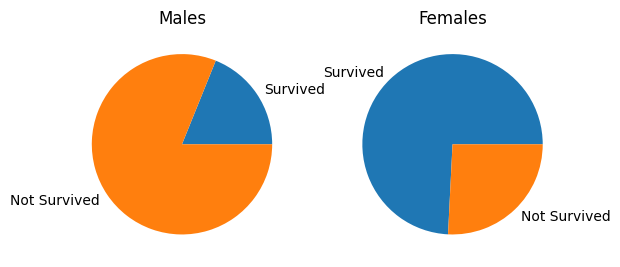

In [5]:
# TODO: Plot 1:
#Survival rates for both males and females

sur_rates = df['Survived']
gender = df['Sex']
males_sur = (df['Sex'] == "male") & (df['Survived'] == 1)
males_not_sur = (df['Sex'] == "male") & (df['Survived'] == 0)
females_sur = (df['Sex'] == "female") & (df['Survived'] == 1)
females_not_sur = (df['Sex'] == "female") & (df['Survived'] == 0)
fig, (ax_male, ax_fem) = plt.subplots(1, 2)
ax_male.pie([males_sur.sum(), males_not_sur.sum()], labels=['Survived', 'Not Survived'])
ax_fem.pie([females_sur.sum(), females_not_sur.sum()], labels=['Survived', 'Not Survived'])
ax_male.set_title('Males')
ax_fem.set_title('Females')
plt.show()

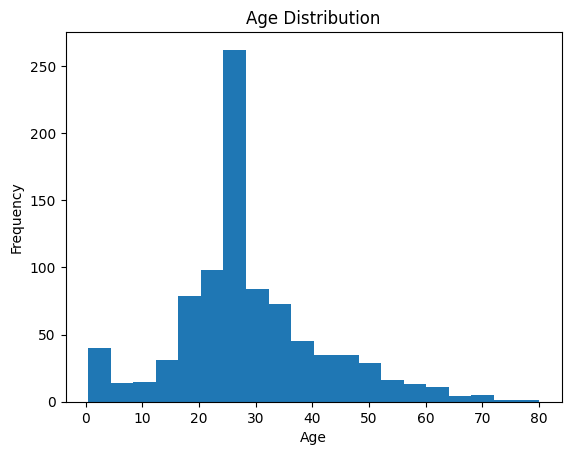

In [7]:
# TODO: Plot 2
#Age Distribution:

ages = df['Age']
fig, ax = plt.subplots()
ax.hist(ages, bins=20)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age Distribution')
plt.show()

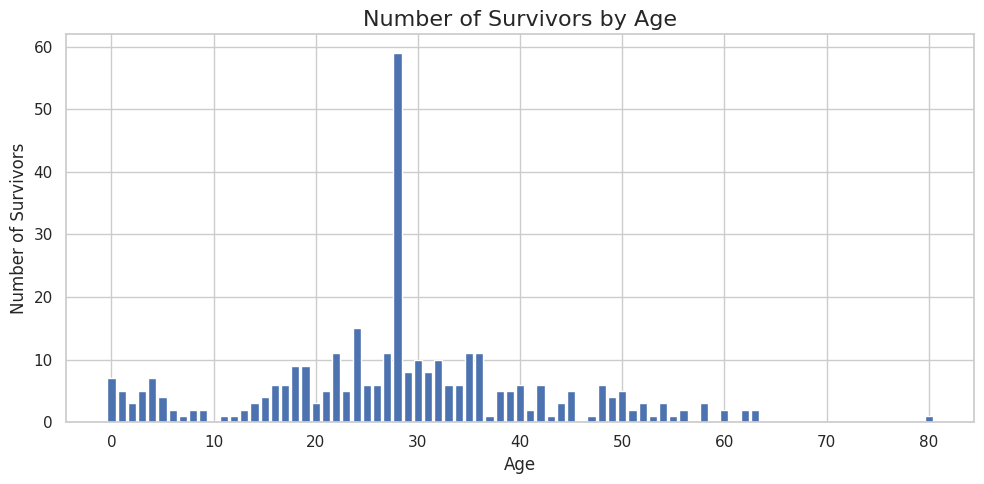

In [19]:
# TODO: Plot 3
#Survival Across ages

sns.set_theme(style="whitegrid")

# fig, ax = plt.subplots()
sur_sortedage = [0] * int(ages.max()+1)
for(age, sur) in zip(ages, sur_rates):
  if sur == 1: sur_sortedage[int(age)] = sur_sortedage[int(age)] + 1

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(len(sur_sortedage)), sur_sortedage)

ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Number of Survivors", fontsize=12)
ax.set_title("Number of Survivors by Age", fontsize=16)

plt.tight_layout()
plt.show()